# Exploratory Data Analysis (EDA) - California Housing Dataset

https://www.kaggle.com/datasets/shibumohapatra/house-price

In [8]:
import kagglehub
import shutil
import os

download_path = kagglehub.dataset_download("shibumohapatra/house-price")

print("Path to dataset files:", download_path)
# 2. Đường dẫn thư mục muốn lưu (Ví dụ: thư mục 'data' ngay tại thư mục code hiện tại)
target_path = "../data/raw"

# 3. Copy toàn bộ dữ liệu sang thư mục mới
if os.path.exists(target_path):
    shutil.rmtree(target_path) # Xóa nếu thư mục đã tồn tại để tránh lỗi
shutil.copytree(download_path, target_path)

print("Dữ liệu đã được lưu tại:", os.path.abspath(target_path))

c:\Users\Win 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Win 11\.cache\kagglehub\datasets\shibumohapatra\house-price\versions\3
Dữ liệu đã được lưu tại: c:\Users\Win 11\Documents\ML\ML_proj_26\lab4\data\raw


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Libraries imported successfully.


## Bước 1. Tổng Quan Dữ Liệu & Kiểu Dữ Liệu (Data Overview & Data Types)

We load the dataset, check its dimensions, inspect column types, and preview samples.

In [10]:
# Read data
data = pd.read_csv('../data/raw/1553768847-housing.csv')
print(f"Kích thước dữ liệu: {data.shape[0]} dòng, {data.shape[1]} cột\n")
print("Thông tin kiểu dữ liệu các cột:")
data.info()
print("\nXem trước 5 dòng đầu:")
display(data.head())

Kích thước dữ liệu: 20640 dòng, 10 cột

Thông tin kiểu dữ liệu các cột:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB

Xem trước 5 dòng đầu:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


## Bước 2. Thống Kê Tổng Hợp (Summary Statistics)

Calculate mean, median, standard deviation, percentiles, min/max for numerical features, and frequency distributions for categorical features.

In [11]:
print("Thống kê tổng hợp biến số:")
display(data.describe())

print("\nThống kê tổng hợp biến phân loại (ocean_proximity):")
display(data.describe(include=['O']))

print("\nTần suất các nhãn trong ocean_proximity:")
display(data['ocean_proximity'].value_counts())

Thống kê tổng hợp biến số:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



Thống kê tổng hợp biến phân loại (ocean_proximity):


C:\Users\Win 11\AppData\Local\Temp\ipykernel_5784\797535771.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(data.describe(include=['O']))


,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136



Tần suất các nhãn trong ocean_proximity:


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## Bước 3. Phân Tích Đơn Biến & Phân Phối (Univariate Analysis & Distributions)

We plot the distribution of target variable `median_house_value` and features like `median_income` and `ocean_proximity` class distributions.

C:\Users\Win 11\AppData\Local\Temp\ipykernel_5784\636733916.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ocean_proximity', data=data, palette='Set2')


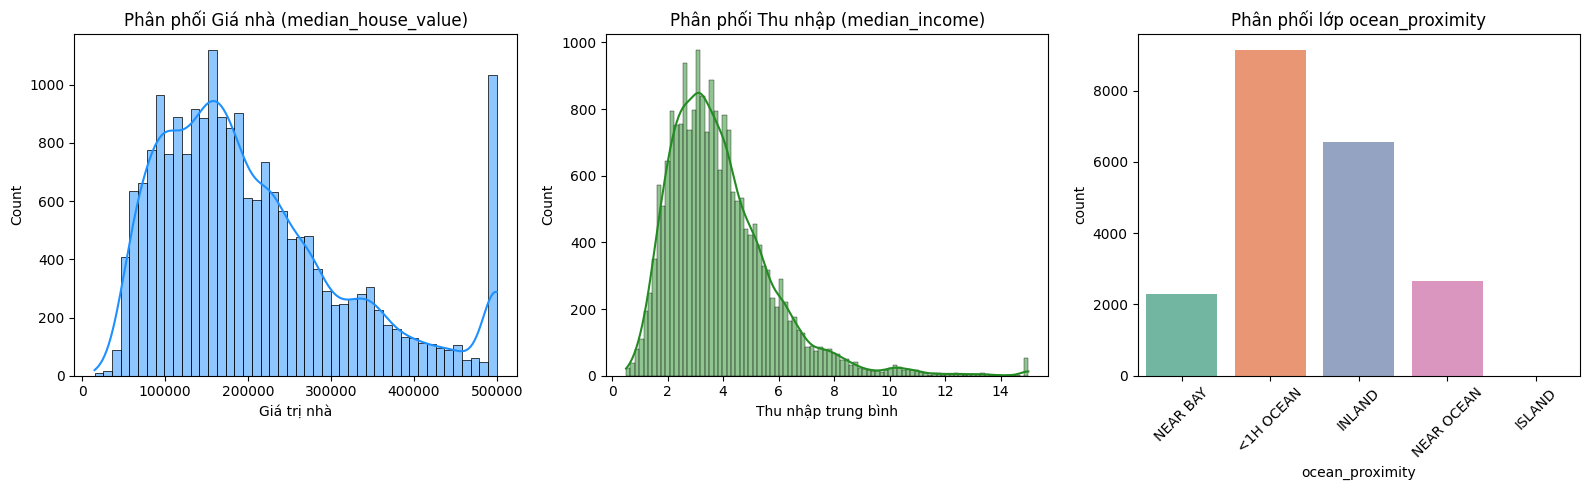

In [12]:
plt.figure(figsize=(16, 5))

# 1. Plot Target Variable Distribution
plt.subplot(1, 3, 1)
sns.histplot(data['median_house_value'], kde=True, color='dodgerblue')
plt.title('Phân phối Giá nhà (median_house_value)')
plt.xlabel('Giá trị nhà')

# 2. Plot Median Income Distribution
plt.subplot(1, 3, 2)
sns.histplot(data['median_income'], kde=True, color='forestgreen')
plt.title('Phân phối Thu nhập (median_income)')
plt.xlabel('Thu nhập trung bình')

# 3. Plot Ocean Proximity Value Counts
plt.subplot(1, 3, 3)
sns.countplot(x='ocean_proximity', data=data, palette='Set2')
plt.title('Phân phối lớp ocean_proximity')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bước 4. Phân Tích Song Biến & Tương Quan (Bivariate Analysis, Correlation & Patterns)

Evaluate correlation matrix of numerical features and visualize key bivariate trends (like income vs house value, geographical distribution, and ocean proximity vs house value).

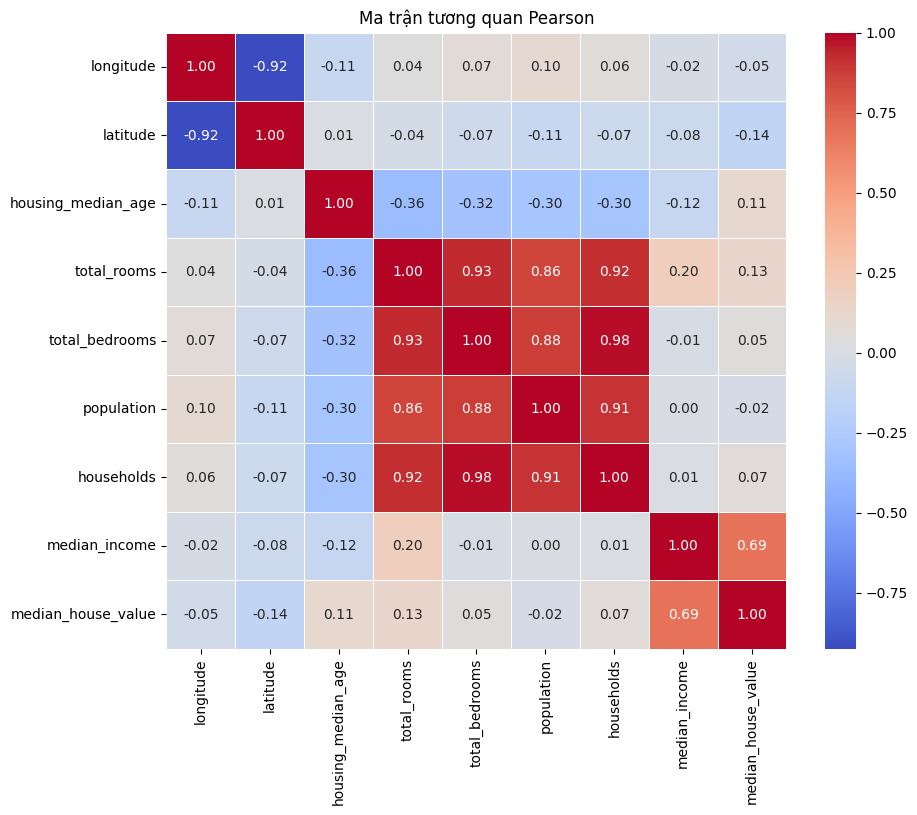

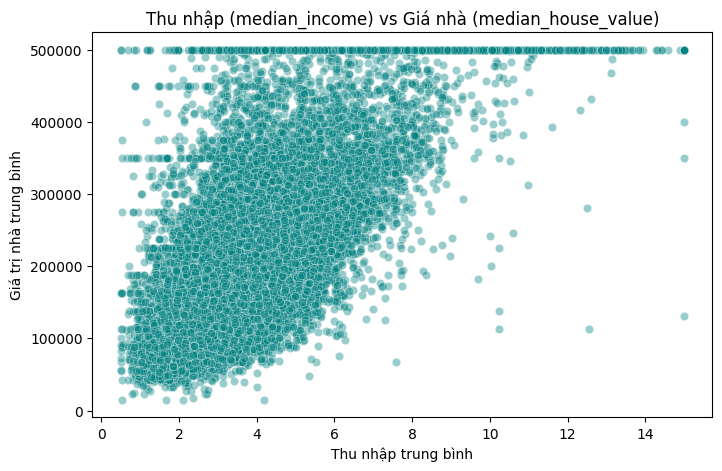

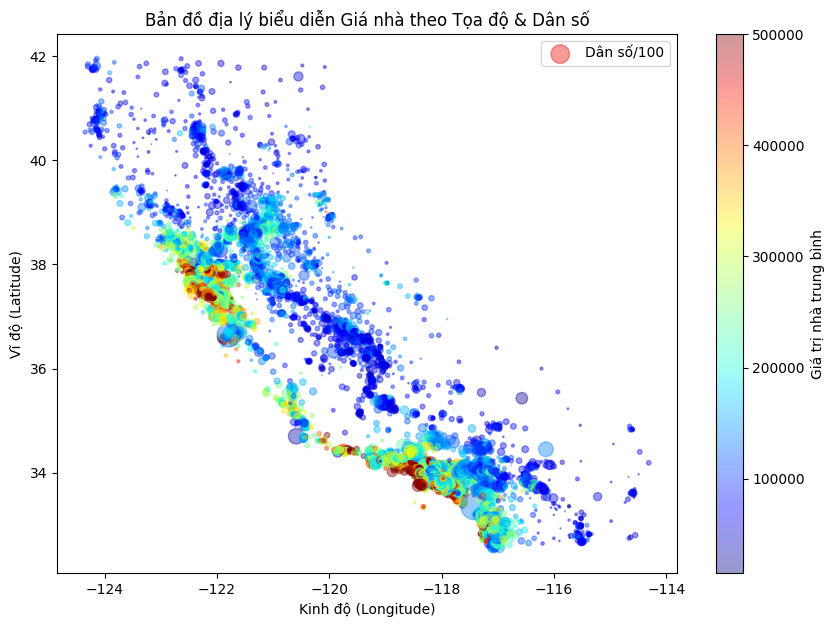

C:\Users\Win 11\AppData\Local\Temp\ipykernel_5784\236675990.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ocean_proximity', y='median_house_value', data=data, palette='Set3')


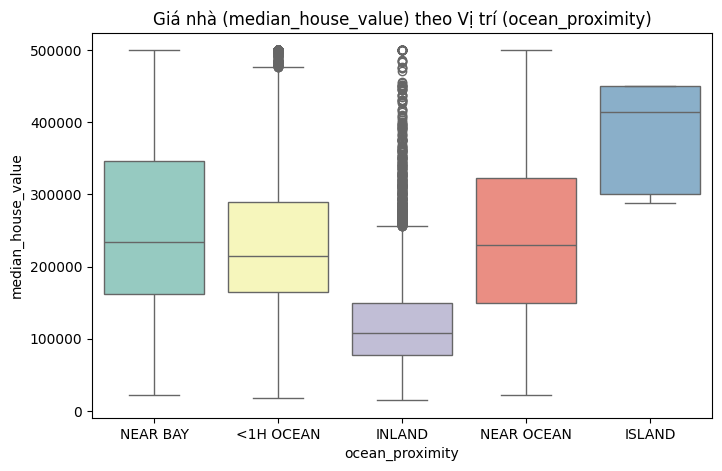

In [ ]:
# 1. Correlation Matrix Heatmap
num_data = data.select_dtypes(include=[np.number])
corr = num_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan Pearson')
plt.show()

# 2. Scatter plot: Median Income vs Median House Value
plt.figure(figsize=(8, 5))
sns.scatterplot(x='median_income', y='median_house_value', data=data, alpha=0.4, color='teal')
plt.title('Thu nhập (median_income) vs Giá nhà (median_house_value)')
plt.xlabel('Thu nhập trung bình')
plt.ylabel('Giá trị nhà trung bình')
plt.show()

# 3. Geographical scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(x=data['longitude'], y=data['latitude'], alpha=0.4, c=data['median_house_value'], cmap=plt.get_cmap('jet'), s=data['population']/100, label='Dân số/100')
plt.colorbar(label='Giá trị nhà trung bình')
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')
plt.title('Bản đồ địa lý biểu diễn Giá nhà theo Tọa độ & Dân số')
plt.legend()
plt.show()

# 4. Box plot: Ocean Proximity vs Median House Value
plt.figure(figsize=(8, 5))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=data, palette='Set3')
plt.title('Giá nhà (median_house_value) theo Vị trí (ocean_proximity)')
plt.show()

## Bước 5. Nhận Diện Dữ Liệu Thiếu, Trùng Lặp & Ngoại Lệ (Missing Data, Duplicate Data & Outliers)

Identify missing values (counts/percentages), check for duplicate rows, and analyze outlier bounds using the IQR method.

In [14]:
# 1. Check Missing Data
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
df_missing = pd.DataFrame({'Cột': missing.index, 'Số ô thiếu': missing.values, 'Tỷ lệ (%)': missing_pct.values})
print("Thống kê khuyết thiếu dữ liệu:")
display(df_missing)

# 2. Check Duplicates
dup_count = data.duplicated().sum()
print(f"\nSố hàng dữ liệu trùng lặp hoàn toàn: {dup_count}")

# 3. Outlier detection using IQR (for columns total_rooms, total_bedrooms, population, households, median_income)
outlier_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
print("\nThống kê số lượng ngoại lệ (Outliers) dựa trên IQR (1.5x IQR):")
for col in outlier_cols:
    col_values = data[col].dropna()
    q1 = col_values.quantile(0.25)
    q3 = col_values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    num_outliers = ((col_values < lower_bound) | (col_values > upper_bound)).sum()
    pct_outliers = (num_outliers / len(col_values)) * 100
    print(f"  Cột {col:15} -> Số ngoại lệ: {num_outliers:6d} ({pct_outliers:5.2f}%)")

Thống kê khuyết thiếu dữ liệu:


,Cột,Số ô thiếu,Tỷ lệ (%)
0,longitude,0,0.000000
1,latitude,0,0.000000
2,housing_median_age,0,0.000000
3,total_rooms,0,0.000000
4,total_bedrooms,207,1.002907
5,population,0,0.000000
6,households,0,0.000000
7,median_income,0,0.000000
8,ocean_proximity,0,0.000000
9,median_house_value,0,0.000000



Số hàng dữ liệu trùng lặp hoàn toàn: 0

Thống kê số lượng ngoại lệ (Outliers) dựa trên IQR (1.5x IQR):
  Cột total_rooms     -> Số ngoại lệ:   1287 ( 6.24%)
  Cột total_bedrooms  -> Số ngoại lệ:   1271 ( 6.22%)
  Cột population      -> Số ngoại lệ:   1196 ( 5.79%)
  Cột households      -> Số ngoại lệ:   1220 ( 5.91%)
  Cột median_income   -> Số ngoại lệ:    681 ( 3.30%)


## Bước 6. Đánh Giá Chất Lượng Dữ Liệu & Trực Quan Hóa (Data Quality & Data Visualization)

Provide a summary of data quality issues and plot a chart summarizing data completeness.

C:\Users\Win 11\AppData\Local\Temp\ipykernel_5784\2748994841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=completeness.values, y=completeness.index, palette='Blues_r')


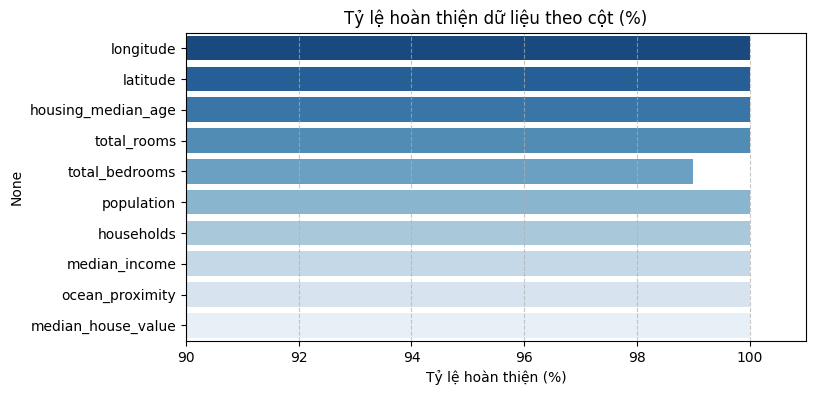


--- Tóm tắt Đánh giá Chất lượng Dữ liệu ---
1. Dữ liệu thiếu: Cột 'total_bedrooms' khuyết 207 dòng (khoảng 1%), các cột khác đầy đủ. Cần điền khuyết bằng Median.
2. Dữ liệu trùng lặp: Không có hàng trùng lặp hoàn toàn.
3. Phân phối và Outliers: Biến mục tiêu 'median_house_value' bị giới hạn chặn trên ở mức $500,001 (đỉnh giả ở cuối phân phối).
   Các biến quy mô (total_rooms, total_bedrooms, population, households) bị phân phối lệch phải rất mạnh, cần log-transform.
   Thu nhập 'median_income' là đặc trưng có tương quan cao nhất với giá nhà (r = 0.69).


In [15]:
# Visualize data completeness
completeness = (1 - (data.isnull().sum() / len(data))) * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=completeness.values, y=completeness.index, palette='Blues_r')
plt.title('Tỷ lệ hoàn thiện dữ liệu theo cột (%)')
plt.xlim(90, 101)
plt.xlabel('Tỷ lệ hoàn thiện (%)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Tóm tắt Đánh giá Chất lượng Dữ liệu ---")
print("1. Dữ liệu thiếu: Cột 'total_bedrooms' khuyết 207 dòng (khoảng 1%), các cột khác đầy đủ. Cần điền khuyết bằng Median.")
print("2. Dữ liệu trùng lặp: Không có hàng trùng lặp hoàn toàn.")
print("3. Phân phối và Outliers: Biến mục tiêu 'median_house_value' bị giới hạn chặn trên ở mức $500,001 (đỉnh giả ở cuối phân phối).")
print("   Các biến quy mô (total_rooms, total_bedrooms, population, households) bị phân phối lệch phải rất mạnh, cần log-transform.")
print("   Thu nhập 'median_income' là đặc trưng có tương quan cao nhất với giá nhà (r = 0.69).")